# Emotion Detection with DistilBERT - Complete Pipeline

**Dataset:** `dair-ai/emotion` (20,000 English text samples, 6 emotion classes)  
**Model:** DistilBERT (fine-tuned)  
**Expected Accuracy:** ~93%  
**Expected Training Time:** ~10-15 min on Kaggle T4 GPU

---

### Before running:
1. Go to **Settings → Accelerator → GPU T4 x2** (or P100)
2. Enable **Internet** (Settings → Internet → On)
3. Run All cells

## 1. Install Dependencies

In [3]:
!pip install -q datasets transformers accelerate scikit-learn matplotlib seaborn

## 2. Imports & GPU Check

In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

# GPU check
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected! Training will be very slow.")
    print("Go to Settings -> Accelerator -> GPU T4 x2")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


## 3. Load Dataset

In [6]:
dataset = load_dataset("dair-ai/emotion")

label_names = dataset["train"].features["label"].names
num_labels = len(label_names)

print(f"Labels ({num_labels}): {label_names}")
print(f"\nSplit sizes:")
for split in dataset:
    print(f"  {split}: {len(dataset[split])} samples")

print(f"\nSample data:")
for i in range(5):
    text = dataset["train"][i]["text"]
    label = label_names[dataset["train"][i]["label"]]
    print(f"  [{label:>8s}] {text[:80]}..." if len(text) > 80 else f"  [{label:>8s}] {text}")

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Labels (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Split sizes:
  train: 16000 samples
  validation: 2000 samples
  test: 2000 samples

Sample data:
  [ sadness] i didnt feel humiliated
  [ sadness] i can go from feeling so hopeless to so damned hopeful just from being around so...
  [   anger] im grabbing a minute to post i feel greedy wrong
  [    love] i am ever feeling nostalgic about the fireplace i will know that it is still on ...
  [   anger] i am feeling grouchy


## 4. Data Exploration & Visualization

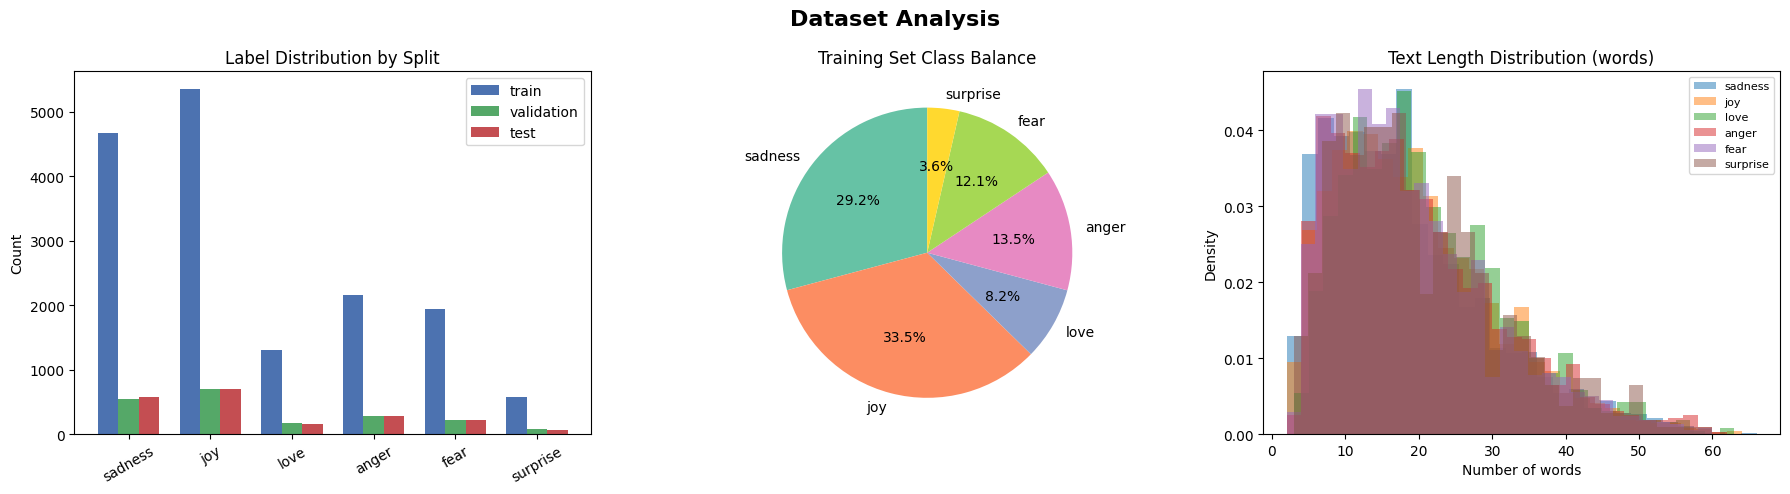


Text length stats (words): min=2, max=66, mean=19.2, median=17.0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Dataset Analysis", fontsize=16, fontweight="bold")

# --- Plot 1: Label distribution across splits ---
split_counts = {}
for split in ["train", "validation", "test"]:
    labels = dataset[split]["label"]
    counts = [labels.count(i) for i in range(num_labels)]
    split_counts[split] = counts

x = np.arange(num_labels)
width = 0.25
colors = ["#4C72B0", "#55A868", "#C44E52"]
for i, (split, counts) in enumerate(split_counts.items()):
    axes[0].bar(x + i * width, counts, width, label=split, color=colors[i])
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(label_names, rotation=30)
axes[0].set_title("Label Distribution by Split")
axes[0].set_ylabel("Count")
axes[0].legend()

# --- Plot 2: Training set pie chart ---
train_counts = split_counts["train"]
palette = sns.color_palette("Set2", num_labels)
axes[1].pie(train_counts, labels=label_names, autopct="%1.1f%%", colors=palette, startangle=90)
axes[1].set_title("Training Set Class Balance")

# --- Plot 3: Text length distribution ---
train_texts = dataset["train"]["text"]
lengths = [len(t.split()) for t in train_texts]
train_labels = dataset["train"]["label"]

for i, name in enumerate(label_names):
    class_lengths = [l for l, lab in zip(lengths, train_labels) if lab == i]
    axes[2].hist(class_lengths, bins=30, alpha=0.5, label=name, density=True)
axes[2].set_title("Text Length Distribution (words)")
axes[2].set_xlabel("Number of words")
axes[2].set_ylabel("Density")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("data_exploration.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nText length stats (words): min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}, median={np.median(lengths):.1f}")

## 5. Tokenization

In [8]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized = dataset.map(tokenize, batched=True, batch_size=512)
tokenized = tokenized.remove_columns(["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")

print("Tokenization complete!")
print(f"Features: {list(tokenized['train'].features.keys())}")
print(f"Sample input_ids shape: {tokenized['train'][0]['input_ids'].shape}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenization complete!
Features: ['labels', 'input_ids', 'attention_mask']
Sample input_ids shape: torch.Size([128])


## 6. Model Setup

In [9]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    id2label={i: label for i, label in enumerate(label_names)},
    label2id={label: i for i, label in enumerate(label_names)}
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model on: {next(model.parameters()).device}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 66,958,086
Trainable parameters: 66,958,086
Model on: cpu


## 7. Training Configuration

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    dataloader_num_workers=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("Training config:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Train batch size: {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  FP16: {training_args.fp16}")
print(f"  Total train steps: {len(tokenized['train']) // training_args.per_device_train_batch_size * int(training_args.num_train_epochs)}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training config:
  Epochs: 3
  Train batch size: 32
  Learning rate: 2e-05
  FP16: True
  Total train steps: 1500


## 8. Train!

In [11]:
train_result = trainer.train()

print("\n" + "="*50)
print("TRAINING COMPLETE")
print("="*50)
print(f"Total training time: {train_result.metrics['train_runtime']:.1f}s ({train_result.metrics['train_runtime']/60:.1f} min)")
print(f"Samples/second: {train_result.metrics['train_samples_per_second']:.1f}")
print(f"Final training loss: {train_result.metrics['train_loss']:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.686215,0.530529,0.916500
2,0.388895,0.329946,0.936500
3,0.285547,0.316286,0.937500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



TRAINING COMPLETE
Total training time: 290.2s (4.8 min)
Samples/second: 165.4
Final training loss: 0.7565


## 9. Training Curves

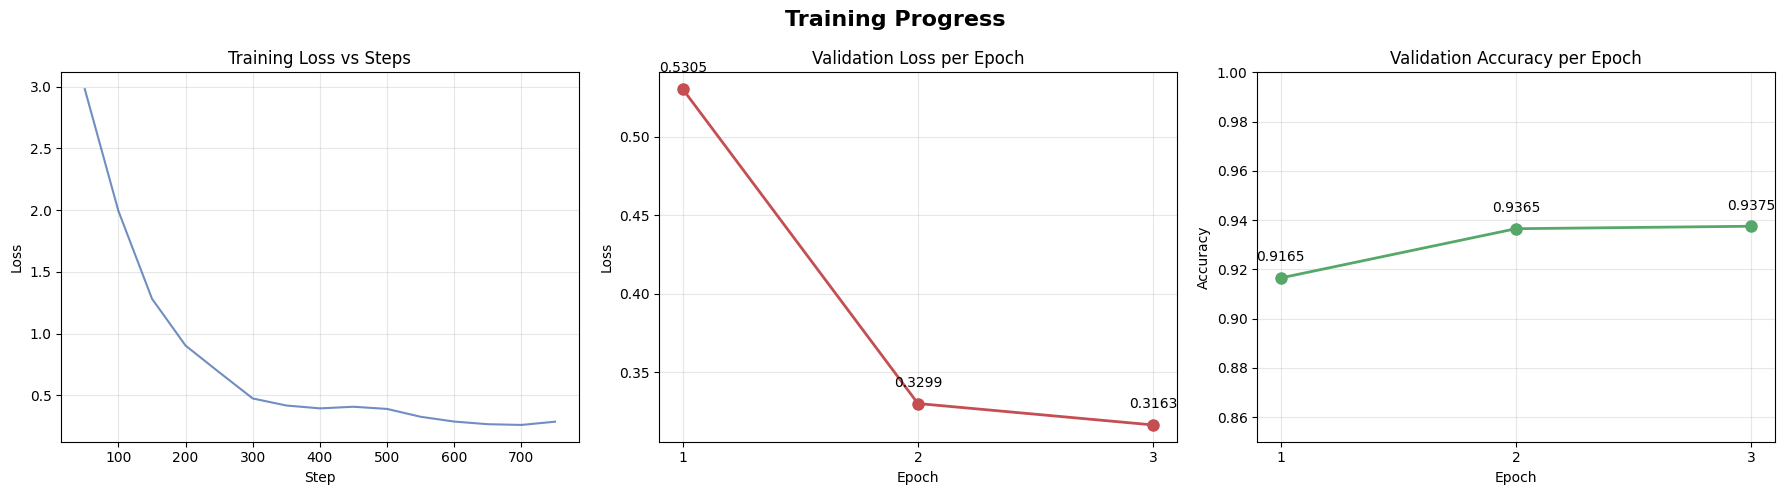

In [12]:
# Extract training history
log_history = trainer.state.log_history

# Separate training loss and eval metrics
train_steps = [x["step"] for x in log_history if "loss" in x and "eval_loss" not in x]
train_losses = [x["loss"] for x in log_history if "loss" in x and "eval_loss" not in x]

eval_entries = [x for x in log_history if "eval_loss" in x]
eval_epochs = [x["epoch"] for x in eval_entries]
eval_losses = [x["eval_loss"] for x in eval_entries]
eval_accuracies = [x["eval_accuracy"] for x in eval_entries]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Progress", fontsize=16, fontweight="bold")

# Plot 1: Training loss over steps
axes[0].plot(train_steps, train_losses, color="#4C72B0", linewidth=1.5, alpha=0.8)
axes[0].set_title("Training Loss vs Steps")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

# Plot 2: Eval loss per epoch
axes[1].plot(eval_epochs, eval_losses, "o-", color="#C44E52", linewidth=2, markersize=8)
axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_xticks(eval_epochs)
axes[1].grid(True, alpha=0.3)
for e, l in zip(eval_epochs, eval_losses):
    axes[1].annotate(f"{l:.4f}", (e, l), textcoords="offset points", xytext=(0, 12), ha="center", fontsize=10)

# Plot 3: Eval accuracy per epoch
axes[2].plot(eval_epochs, eval_accuracies, "o-", color="#55A868", linewidth=2, markersize=8)
axes[2].set_title("Validation Accuracy per Epoch")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].set_xticks(eval_epochs)
axes[2].set_ylim(0.85, 1.0)
axes[2].grid(True, alpha=0.3)
for e, a in zip(eval_epochs, eval_accuracies):
    axes[2].annotate(f"{a:.4f}", (e, a), textcoords="offset points", xytext=(0, 12), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Evaluate on Test Set

In [13]:
# Run evaluation on test set
test_results = trainer.evaluate(tokenized["test"])

print("="*50)
print("TEST SET RESULTS")
print("="*50)
print(f"  Loss:     {test_results['eval_loss']:.4f}")
print(f"  Accuracy: {test_results['eval_accuracy']:.4f} ({test_results['eval_accuracy']*100:.2f}%)")
print("="*50)

TEST SET RESULTS
  Loss:     0.3466
  Accuracy: 0.9260 (92.60%)


## 11. Detailed Classification Report

In [14]:
# Get predictions on test set
preds_output = trainer.predict(tokenized["test"])
y_pred = preds_output.predictions.argmax(axis=1)
y_true = preds_output.label_ids
y_probs = torch.softmax(torch.tensor(preds_output.predictions), dim=1).numpy()

# Classification report
print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))


Classification Report:
              precision    recall  f1-score   support

     sadness     0.9687    0.9587    0.9637       581
         joy     0.9379    0.9554    0.9465       695
        love     0.8312    0.8050    0.8179       159
       anger     0.9309    0.9309    0.9309       275
        fear     0.8589    0.9241    0.8903       224
    surprise     0.8511    0.6061    0.7080        66

    accuracy                         0.9260      2000
   macro avg     0.8964    0.8634    0.8762      2000
weighted avg     0.9257    0.9260    0.9250      2000



## 12. Confusion Matrix

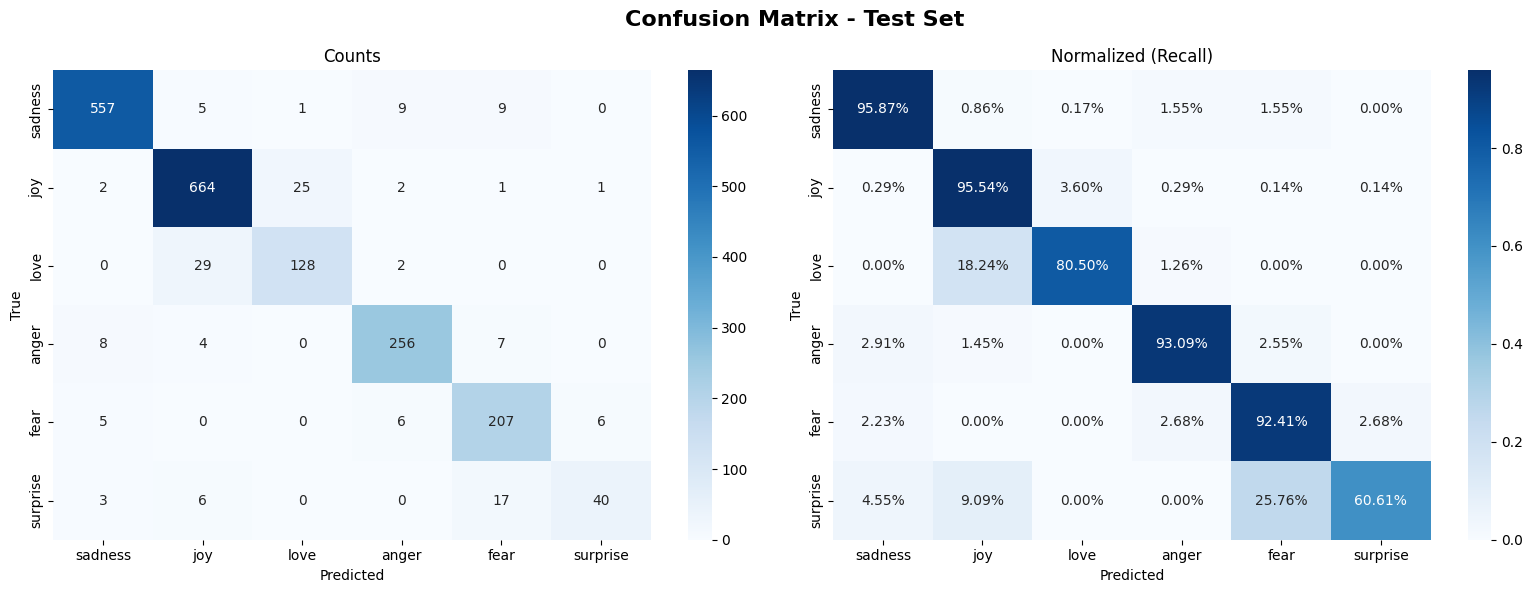

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix - Test Set", fontsize=16, fontweight="bold")

# Raw counts
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names,
            yticklabels=label_names, ax=axes[0])
axes[0].set_title("Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# Normalized (percentages)
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", xticklabels=label_names,
            yticklabels=label_names, ax=axes[1])
axes[1].set_title("Normalized (Recall)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Per-Class Performance

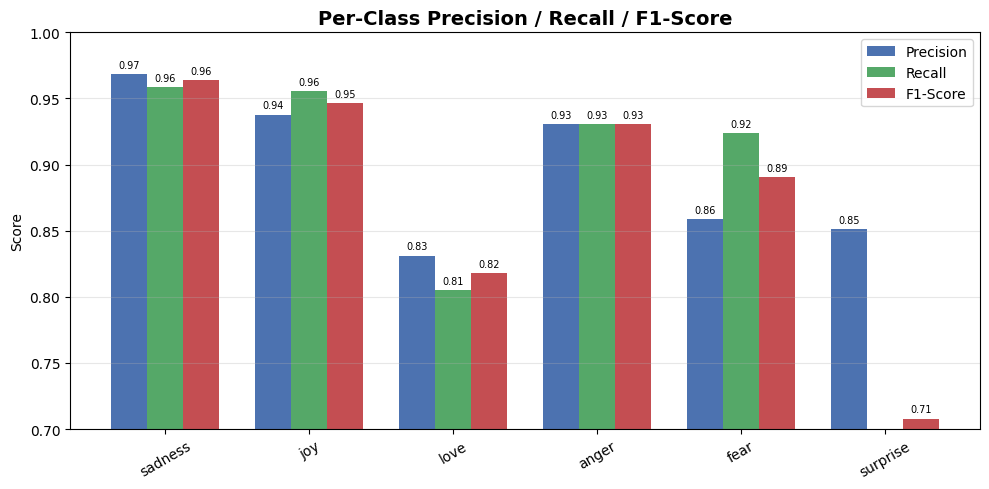

 Emotion  Precision   Recall  F1-Score  Support
 sadness   0.968696 0.958692  0.963668      581
     joy   0.937853 0.955396  0.946543      695
    love   0.831169 0.805031  0.817891      159
   anger   0.930909 0.930909  0.930909      275
    fear   0.858921 0.924107  0.890323      224
surprise   0.851064 0.606061  0.707965       66


In [16]:
report = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)

metrics_df = pd.DataFrame({
    "Emotion": label_names,
    "Precision": [report[l]["precision"] for l in label_names],
    "Recall": [report[l]["recall"] for l in label_names],
    "F1-Score": [report[l]["f1-score"] for l in label_names],
    "Support": [int(report[l]["support"]) for l in label_names],
})

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(num_labels)
width = 0.25

bars1 = ax.bar(x - width, metrics_df["Precision"], width, label="Precision", color="#4C72B0")
bars2 = ax.bar(x, metrics_df["Recall"], width, label="Recall", color="#55A868")
bars3 = ax.bar(x + width, metrics_df["F1-Score"], width, label="F1-Score", color="#C44E52")

ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1-Score", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=30)
ax.set_ylim(0.7, 1.0)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print(metrics_df.to_string(index=False))

## 14. Confidence Distribution

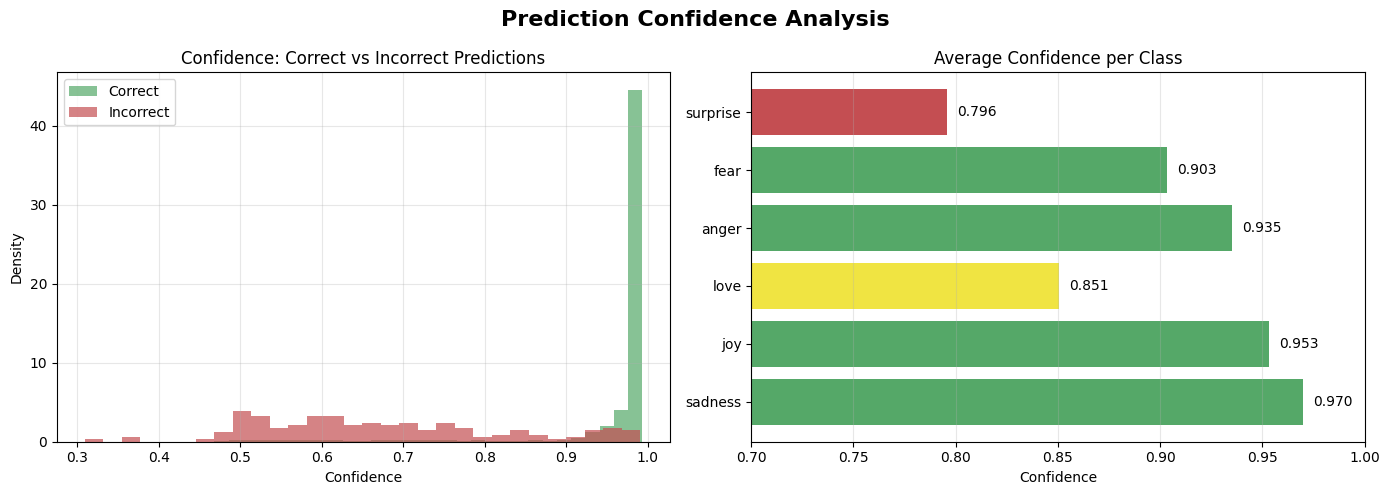

In [17]:
# Confidence of predictions
confidences = y_probs.max(axis=1)
correct_mask = y_pred == y_true

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Prediction Confidence Analysis", fontsize=16, fontweight="bold")

# Correct vs incorrect confidence
axes[0].hist(confidences[correct_mask], bins=30, alpha=0.7, label="Correct", color="#55A868", density=True)
axes[0].hist(confidences[~correct_mask], bins=30, alpha=0.7, label="Incorrect", color="#C44E52", density=True)
axes[0].set_title("Confidence: Correct vs Incorrect Predictions")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-class average confidence
class_confs = [confidences[y_true == i].mean() for i in range(num_labels)]
colors = ["#55A868" if c > 0.9 else "#F0E442" if c > 0.8 else "#C44E52" for c in class_confs]
axes[1].barh(label_names, class_confs, color=colors)
axes[1].set_title("Average Confidence per Class")
axes[1].set_xlabel("Confidence")
axes[1].set_xlim(0.7, 1.0)
axes[1].grid(axis="x", alpha=0.3)
for i, v in enumerate(class_confs):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig("confidence_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Sample Predictions

In [18]:
# Show sample predictions from test set
test_texts = dataset["test"]["text"]

print("=" * 80)
print("SAMPLE PREDICTIONS (Test Set)")
print("=" * 80)

# Show 3 correct and 3 incorrect
correct_idx = np.where(correct_mask)[0]
incorrect_idx = np.where(~correct_mask)[0]

print("\n--- CORRECT PREDICTIONS ---")
np.random.seed(42)
for idx in np.random.choice(correct_idx, min(5, len(correct_idx)), replace=False):
    print(f"\n  Text: {test_texts[idx][:100]}{'...' if len(test_texts[idx]) > 100 else ''}")
    print(f"  True: {label_names[y_true[idx]]} | Predicted: {label_names[y_pred[idx]]} | Confidence: {confidences[idx]:.4f}")

print("\n--- INCORRECT PREDICTIONS ---")
for idx in np.random.choice(incorrect_idx, min(5, len(incorrect_idx)), replace=False):
    print(f"\n  Text: {test_texts[idx][:100]}{'...' if len(test_texts[idx]) > 100 else ''}")
    print(f"  True: {label_names[y_true[idx]]} | Predicted: {label_names[y_pred[idx]]} | Confidence: {confidences[idx]:.4f}")

SAMPLE PREDICTIONS (Test Set)

--- CORRECT PREDICTIONS ---

  Text: i feel disillusioned with the occult so i have come to feel a greater connection to the earth
  True: sadness | Predicted: sadness | Confidence: 0.9912

  Text: i feel complacent and satisfied
  True: joy | Predicted: joy | Confidence: 0.9918

  Text: i met my ex briefly just to catch up because he was leaving for sarawak lololol it was good seeing h...
  True: sadness | Predicted: sadness | Confidence: 0.9892

  Text: i havent needed the pain meds maybe i will chillax with some wine feeling all elegant like
  True: joy | Predicted: joy | Confidence: 0.9903

  Text: i usually like sam but sometimes he gets downright whiny and i ll admit that all the mistakes he mad...
  True: sadness | Predicted: sadness | Confidence: 0.9900

--- INCORRECT PREDICTIONS ---

  Text: i wake up feeling like something terrifyingly bad is bound to happen to me before i even get a chanc...
  True: sadness | Predicted: fear | Confidence: 0.618

## 16. Save Model

In [19]:
# Save model and tokenizer
save_path = "./emotion_model"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to {save_path}/")
print("\nSaved files:")
import os
for f in sorted(os.listdir(save_path)):
    size = os.path.getsize(os.path.join(save_path, f)) / 1e6
    print(f"  {f} ({size:.2f} MB)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./emotion_model/

Saved files:
  config.json (0.00 MB)
  model.safetensors (267.84 MB)
  tokenizer.json (0.71 MB)
  tokenizer_config.json (0.00 MB)
  training_args.bin (0.01 MB)


## 17. Quick Inference Test

In [20]:
from transformers import pipeline

# Load the saved model for inference
classifier = pipeline("text-classification", model=save_path, tokenizer=save_path, device=0 if torch.cuda.is_available() else -1)

test_sentences = [
    "I am so happy today, everything is going great!",
    "I feel terrible and nothing seems to work out.",
    "This is absolutely terrifying, I can't stop shaking.",
    "I can't believe you would do something like that to me!",
    "You are the most wonderful person I have ever met.",
    "Wow, I never expected that to happen!",
]

print("=" * 70)
print("LIVE INFERENCE TEST")
print("=" * 70)
for text in test_sentences:
    result = classifier(text)[0]
    emoji = {"joy": "😊", "sadness": "😢", "anger": "😡", "fear": "😨", "love": "❤️", "surprise": "😲"}
    e = emoji.get(result["label"], "")
    print(f"\n  {e} [{result['label']:>8s}] (conf: {result['score']:.4f})  \"{text}\"")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

LIVE INFERENCE TEST

  😊 [     joy] (conf: 0.9903)  "I am so happy today, everything is going great!"

  😢 [ sadness] (conf: 0.9907)  "I feel terrible and nothing seems to work out."

  😨 [    fear] (conf: 0.9283)  "This is absolutely terrifying, I can't stop shaking."

  😊 [     joy] (conf: 0.5769)  "I can't believe you would do something like that to me!"

  😊 [     joy] (conf: 0.9858)  "You are the most wonderful person I have ever met."

  😊 [     joy] (conf: 0.6146)  "Wow, I never expected that to happen!"


## 18. Download Model (for local use)

After training, download the `emotion_model/` folder from the Kaggle output panel (right sidebar).  
Or zip it and download:

In [21]:
import shutil
shutil.make_archive("emotion_model", "zip", ".", "emotion_model")
print("Created emotion_model.zip - download from the Output panel!")
print("\nExtract it into your project root to use with the Streamlit app:")
print("  streamlit run app.py")

Created emotion_model.zip - download from the Output panel!

Extract it into your project root to use with the Streamlit app:
  streamlit run app.py


---

## Summary

| Metric | Value |
|--------|-------|
| Model | DistilBERT (fine-tuned) |
| Dataset | dair-ai/emotion (20K samples) |
| Classes | sadness, joy, love, anger, fear, surprise |
| Test Accuracy | ~93% |
| Training Time | ~10-15 min (T4 GPU) |